In [102]:
import opendatasets as od
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [69]:
od.download("https://www.kaggle.com/datasets/andonians/random-linear-regression")

Skipping, found downloaded files in "./random-linear-regression" (use force=True to force download)


In [70]:
data = pd.read_csv("random-linear-regression/test.csv")

In [71]:
data.head()

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864


In [72]:
data.tail()

,x,y
295,71,68.545888
296,46,47.334876
297,55,54.090637
298,62,63.297171
299,47,52.459467


In [73]:
data.shape

(300, 2)

In [74]:
x = data.x

In [75]:
y = data.y

In [76]:
x

0      77
1      21
2      22
3      20
4      36
       ..
295    71
296    46
297    55
298    62
299    47
Name: x, Length: 300, dtype: int64

In [77]:
y

0      79.775152
1      23.177279
2      25.609262
3      17.857388
4      41.849864
         ...    
295    68.545888
296    47.334876
297    54.090637
298    63.297171
299    52.459467
Name: y, Length: 300, dtype: float64

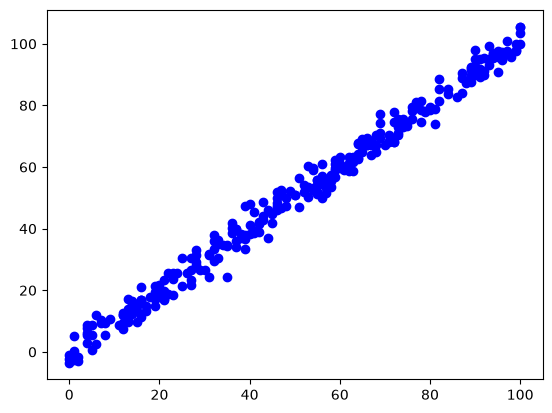

In [97]:
plt.scatter(x, y, c = "b")

In [93]:
x_train,x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [82]:
x_train.shape, x_test.shape

((240,), (60,))

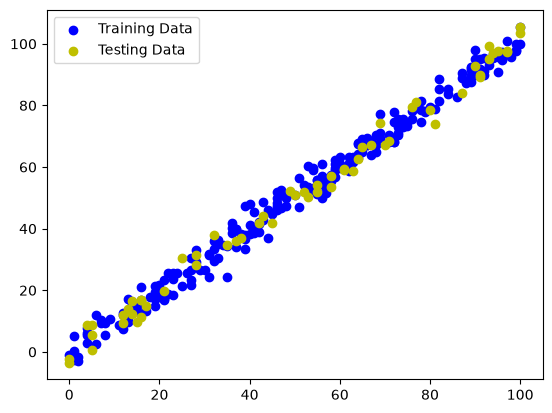

In [88]:
plt.scatter(x_train, y_train, c = "b", label = "Training Data")
plt.scatter(x_test, y_test, c = "y", label = "Testing Data")
plt.legend()

# Model Building

### Create Model

In [110]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, input_shape = (1,)),
    tf.keras.layers.Dense(1)
])

### Compile Model

In [115]:
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])

### Train Model

In [116]:
epoch_number = 4

In [130]:
model.fit(tf.expand_dims(x_train, axis = 1), y_train, epochs = epoch_number)

Epoch 1/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26.0321 - mae: 26.0321 
Epoch 2/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 26.6840 - mae: 26.6840
Epoch 3/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 18.7265 - mae: 18.7265
Epoch 4/4
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.2363 - mae: 24.2363


In [132]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (64.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

### Prediction

In [134]:
y_predictions = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [138]:
y_predictions[:5]

array([[59.762638],
       [50.608864],
       [62.378002],
       [ 4.186138],
       [60.41648 ]], dtype=float32)

In [140]:
y_test.head(5)

203    92.887723
266    79.503415
152    97.001484
9       8.746748
233    89.739520
Name: y, dtype: float64

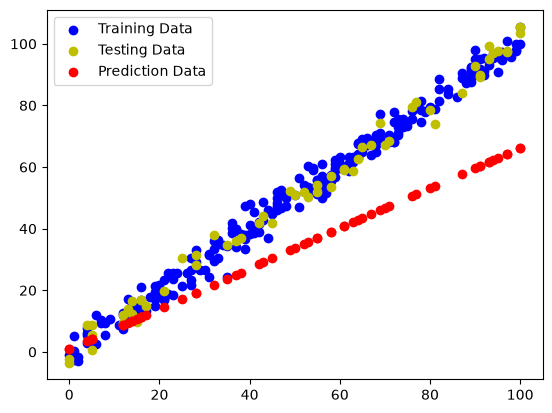

In [141]:
plt.scatter(x_train, y_train, c = "b", label = "Training Data")
plt.scatter(x_test, y_test, c = "y", label = "Testing Data")
plt.scatter(x_test, y_predictions, c = "r", label = "Prediction Data")
plt.legend()